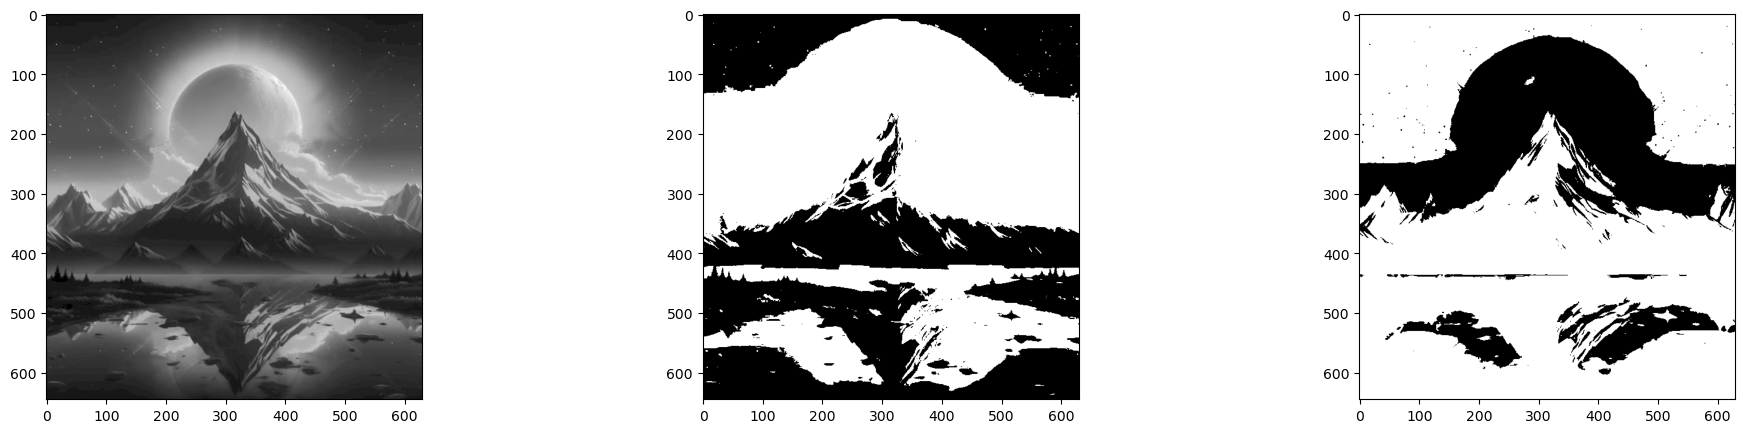

In [1]:
import cv2
import matplotlib.pyplot as plt
imagen = cv2.imread('A.png',0) #lee escala de grises
#umbralizacion binaria 
_,umbral_binario=cv2.threshold(imagen,60,255,cv2.THRESH_BINARY)
#umbralizacion binaria inversa
_,umbral_binario_inv=cv2.threshold(imagen,100,255,cv2.THRESH_BINARY_INV)

plt.figure(figsize=(24,5))

plt.subplot(1,3,1)
plt.imshow(imagen,cmap='gray')

plt.subplot(1,3,2)
plt.imshow(umbral_binario,cmap='gray')

plt.subplot(1,3,3)
plt.imshow(umbral_binario_inv,cmap='gray')

plt.show()

umbralizacion GLOBAL
umbralizacion ISODATA

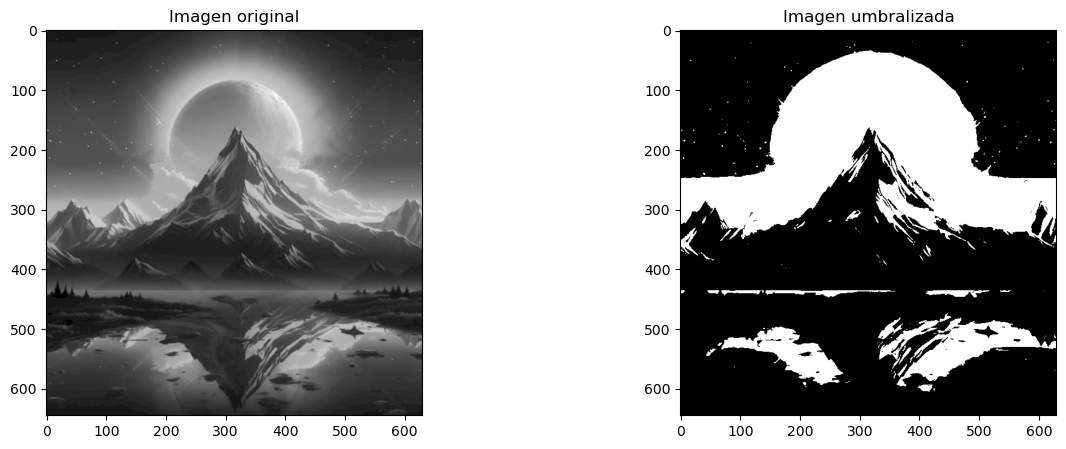

In [8]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt

def isodata(image):
    #decidimos umbral inicial de 0 a 225
    umbral=128 #puedo cambiarlo cuando se requiera 
    while True:
        grupo1=image[image<=umbral]#grupo donde el umbral es menor o igual al valor determidnado
        grupo2=image[image>umbral]#mayor al determinado
        #calculo de la media de cada grupo
        media1=np.mean(grupo1)
        media2=np.mean(grupo2)
        #calculamos nuevo valor del umbral
        nuevo_umbral=(media1+media2)/2
        #si el nuevo umbral es igual al inicial se deteiene

        if abs(nuevo_umbral-umbral)<0.5:
            break
        umbral=nuevo_umbral
    return umbral

imagen=cv2.imread('A.png',0)
umbral_isodata=isodata(imagen)
_,umbralizacion_iso=cv2.threshold(imagen,int(umbral_isodata),255,cv2.THRESH_BINARY)
plt.figure(figsize=(15,5))
# mostrar imagen original y umbralizada
plt.subplot(1,2,1)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen original')


plt.subplot(1,2,2)
plt.imshow(umbralizacion_iso, cmap='gray')
plt.title('Imagen umbralizada')

plt.show()

umbralizacion de 2 picos

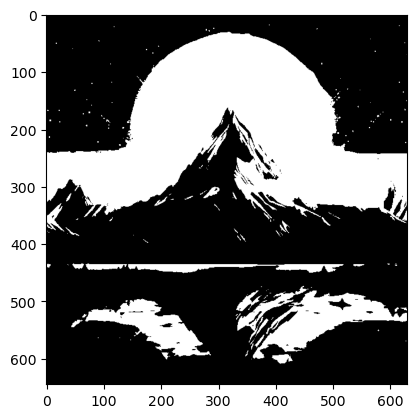

In [11]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt

def dos_picos(image):
    #calculo de hostrograma
    hist=cv2.calcHist([image],[0],None,[256],[0,256])#hago uso de histograma
    #seleccionamos los dos picos
    pico=np.array(hist)
    pico=pico.flatten()
    pico_dif=np.diff(pico)#diferencias entre los picos 
    primer_pico=np.argmax(pico_dif[:128])#pico hasta 127
    segundo_pico=np.argmax(pico_dif[128:])+128 #pico de 128 para adelante
    #calculo del umbral
    umbral=int((primer_pico+segundo_pico)/2)
    return umbral

imagen=cv2.imread('A.png',0)
umbral_2_picos=dos_picos(imagen)
_,nueva=cv2.threshold(imagen,umbral_2_picos,266,cv2.THRESH_BINARY)

plt.imshow(nueva, cmap='gray')
plt.show()

umbralizacion con otsu

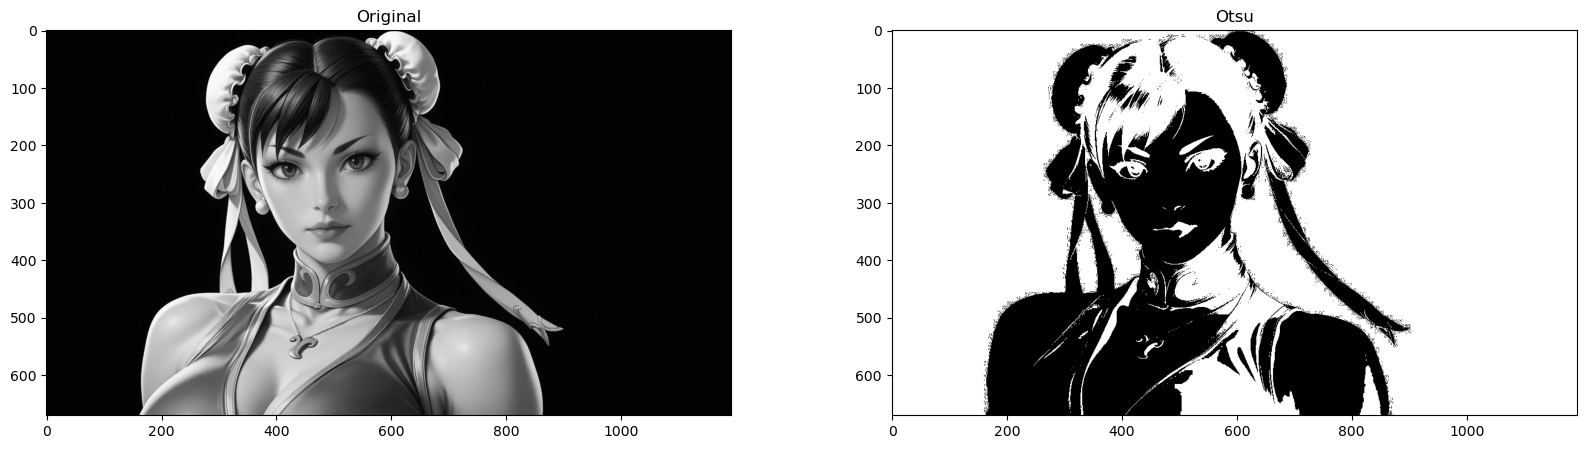

In [7]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt

# Leer imagen en escala de grises
image = cv2.imread('chunli.jpg', 0)

# Aplicar Otsu correctamente
_, otsu = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Resultado final
imagen_fin = np.where(image > otsu, 255, 0).astype(np.uint8)

plt.figure(figsize=(20,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(image, cmap='gray')

plt.subplot(1,2,2)
plt.title("Otsu")
plt.imshow(imagen_fin, cmap='gray')

plt.show()

otsu sin cv2

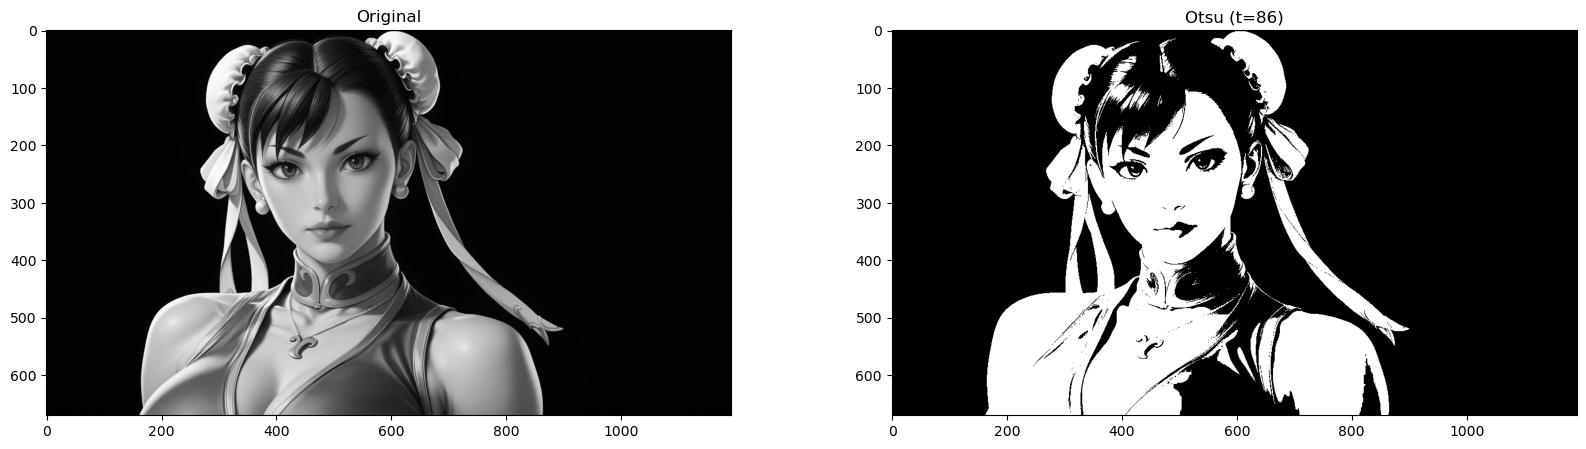

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def otsu_threshold(image):
    hist, bins = np.histogram(image.ravel(), bins=256, range=(0,256))
    p = hist / hist.sum()
    max_var = 0
    threshold = 0
    for t in range(256):
        w0 = p[:t].sum()
        w1 = p[t:].sum()
        if w0 == 0 or w1 == 0:
            continue
        mu0 = np.sum(np.arange(0,t) * p[:t]) / w0
        mu1 = np.sum(np.arange(t,256) * p[t:]) / w1
        var_between = w0 * w1 * (mu0 - mu1)**2
        if var_between > max_var:
            max_var = var_between
            threshold = t
    return threshold

t = otsu_threshold(image)
imagen_fin = np.where(image > t, 255, 0).astype(np.uint8)

plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(image, cmap='gray')

plt.subplot(1,2,2)
plt.title(f"Otsu (t={t})")
plt.imshow(imagen_fin, cmap='gray')
plt.show()

urbanizacion variable
particion de una imagen

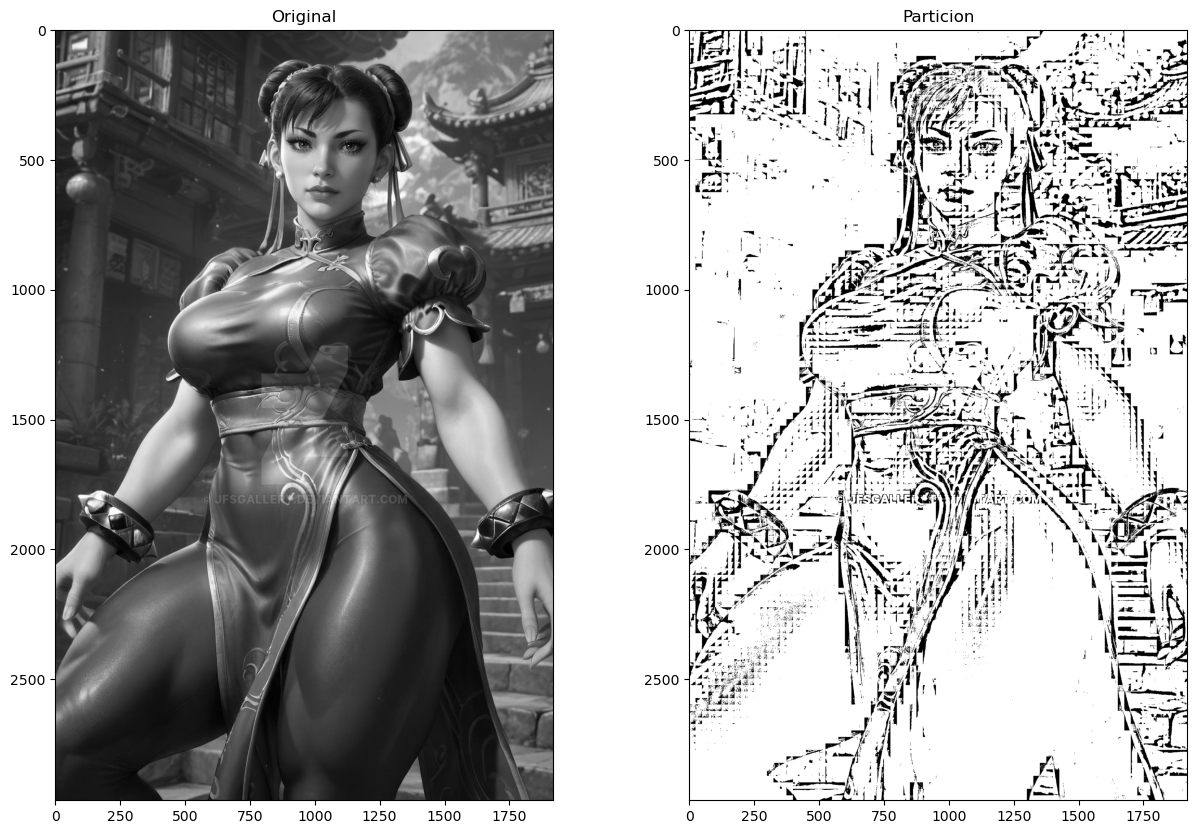

In [8]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt

def variable_part(image, tam_bloque, c):
    umbral_img = np.zeros_like(image)
    
    for y in range(0, image.shape[0], tam_bloque):  # recorremos filas 
        for x in range(0, image.shape[1], tam_bloque):  # recorremos columnas
            bloque = image[y:y+tam_bloque, x:x+tam_bloque]  # bloque
            bloq_media = np.mean(bloque)  # intensidad promedio
            umbral = bloq_media - c
            
            # binarización correcta
            umbral_img[y:y+tam_bloque, x:x+tam_bloque] = np.where(bloque > umbral, 255, 0)
    
    return umbral_img

tam_b = 25
c = 10

image = cv2.imread('chunmuslosli.jpg', 0)
img_fin = variable_part(image, tam_b, c)

plt.figure(figsize=(15,10))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(image, cmap='gray')

plt.subplot(1,2,2)
plt.title("Particion")
plt.imshow(img_fin, cmap='gray')

plt.show()

propiedades locales

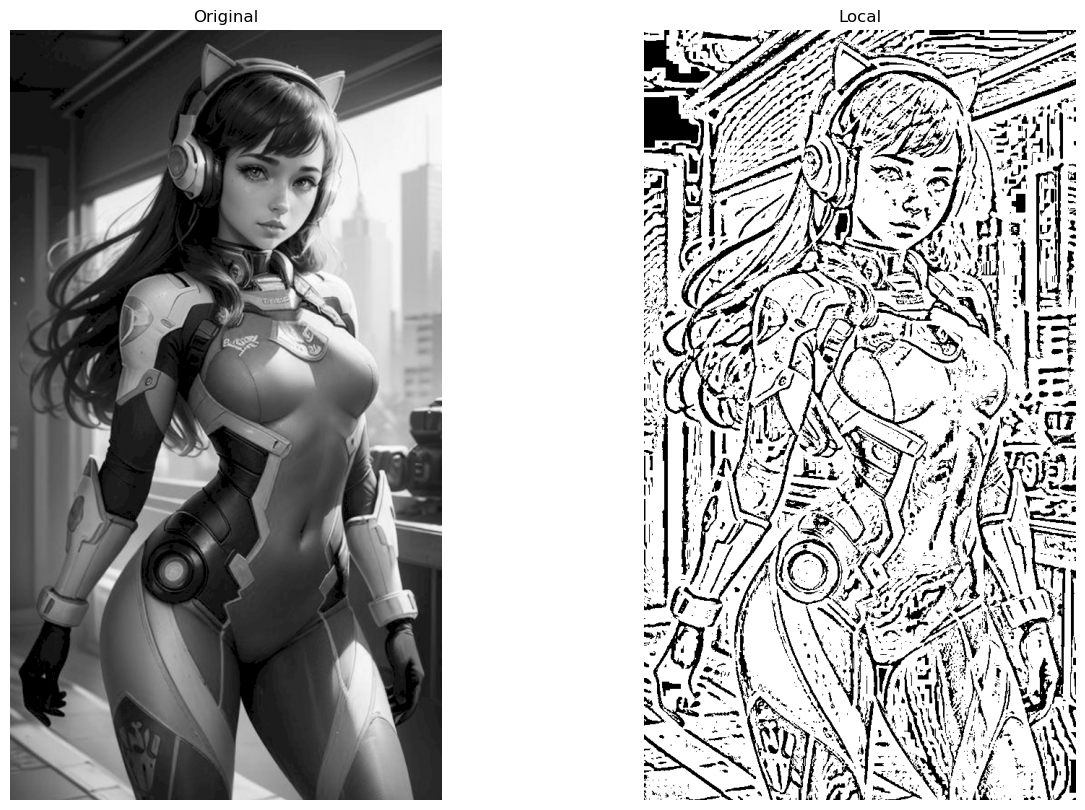

In [9]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt

image = cv2.imread('dva.png', 0)  # escala de grises

def local(image, tamanio_ventana, k):
    umbr_img = np.zeros_like(image)
    
    pad = tamanio_ventana // 2
    padded_image = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_REPLICATE)
    
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            ventana = padded_image[y:y+tamanio_ventana, x:x+tamanio_ventana]
            
            mean_local = np.mean(ventana)
            std_mean = np.std(ventana)
            umbral = mean_local - (k * std_mean)
            
            umbr_img[y, x] = 255 if image[y, x] > umbral else 0
    
    return umbr_img

tam_vent = 15
k = 0.5

img_fin = local(image, tam_vent, k)

plt.figure(figsize=(15,10))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Local")
plt.imshow(img_fin, cmap='gray')
plt.axis('off')

plt.show()

VARIABLE CON OPEN CV

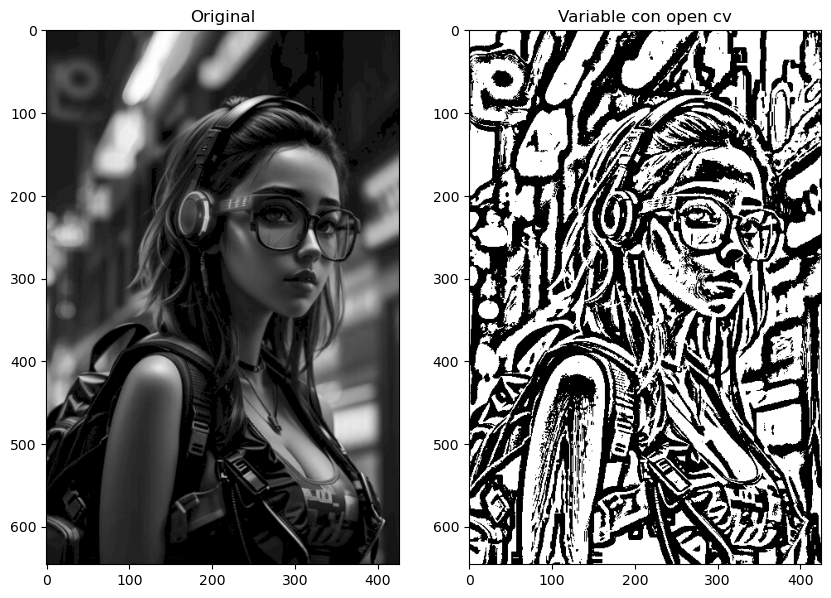

In [5]:
import cv2
import matplotlib.pyplot as plt
image = cv2.imread('ch.png', 0)

ventana = 15
k = 0.5

imagen_fin = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, ventana, k)
plt.figure(figsize=(10,10))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(imagen_fin, cmap='gray')
plt.title('Variable con open cv')


plt.show()

ejemplo 1 

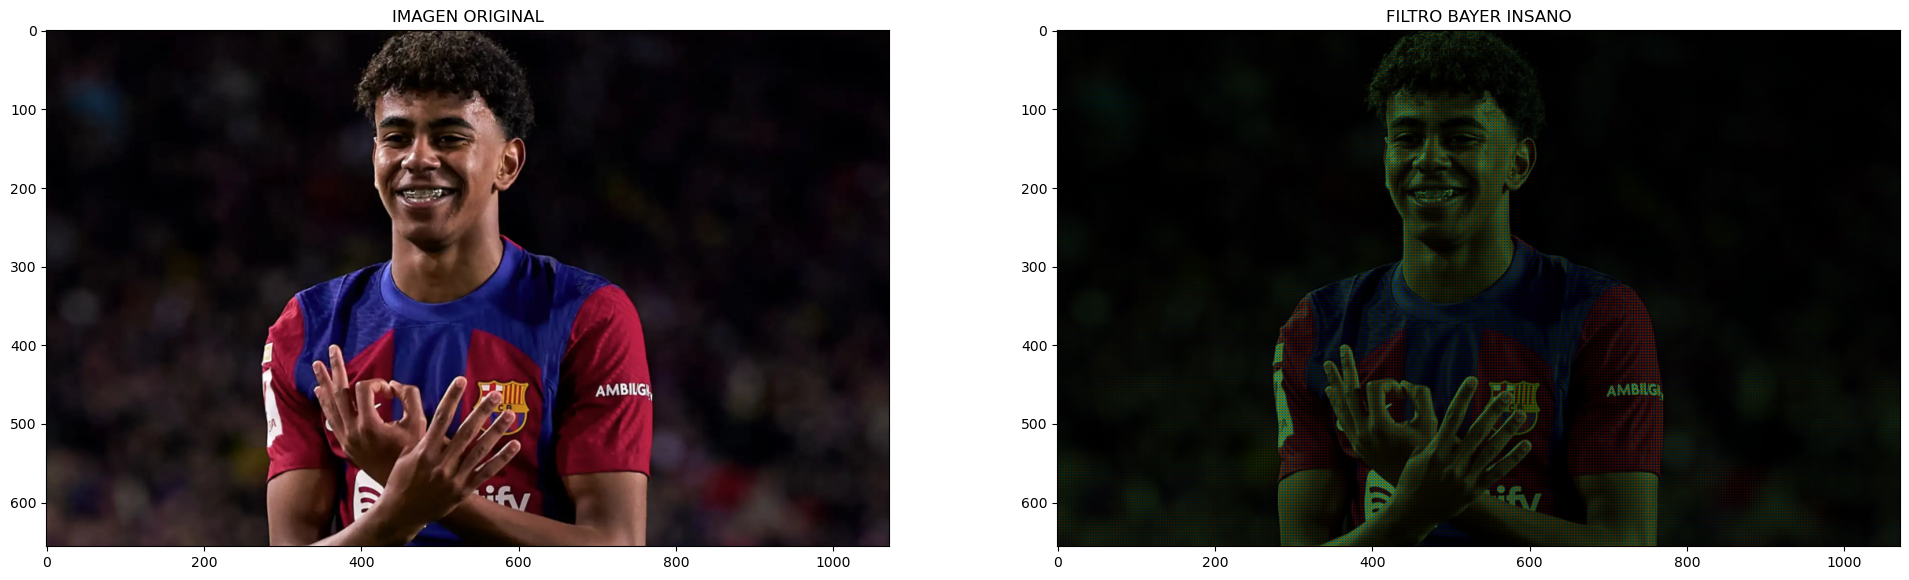

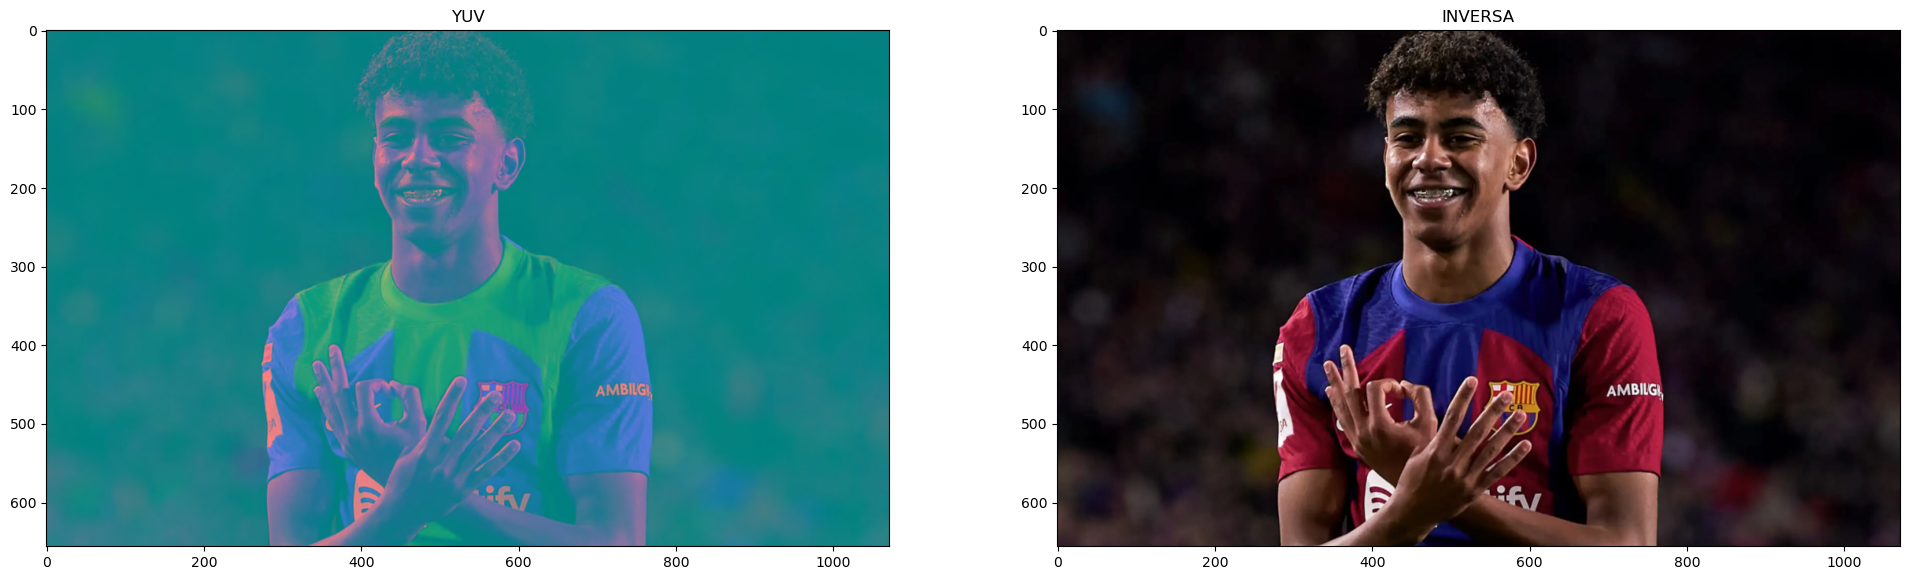

In [1]:
import cv2
import matplotlib.pyplot as plt

img_bgr = cv2.imread('lam.png')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

bayer_color = img_rgb.copy()
bayer_color[0::2, 0::2, :2] = 0 
bayer_color[0::2, 1::2, 0] = 0; bayer_color[0::2, 1::2, 2] = 0
bayer_color[1::2, 0::2, 0] = 0; bayer_color[1::2, 0::2, 2] = 0
bayer_color[1::2, 1::2, 1:] = 0

img_yuv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YUV)
img_rgb_back = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

plt.figure(figsize=(50, 16))

plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title('IMAGEN ORIGINAL')
plt.subplot(1, 4, 2)
plt.title('FILTRO BAYER INSANO')
plt.imshow(bayer_color)
plt.figure(figsize=(50, 16))
plt.subplot(2, 4, 1)
plt.imshow(img_yuv)
plt.title('YUV')
plt.subplot(2, 4, 2)
plt.imshow(img_rgb_back)
plt.title('INVERSA')
plt.show()

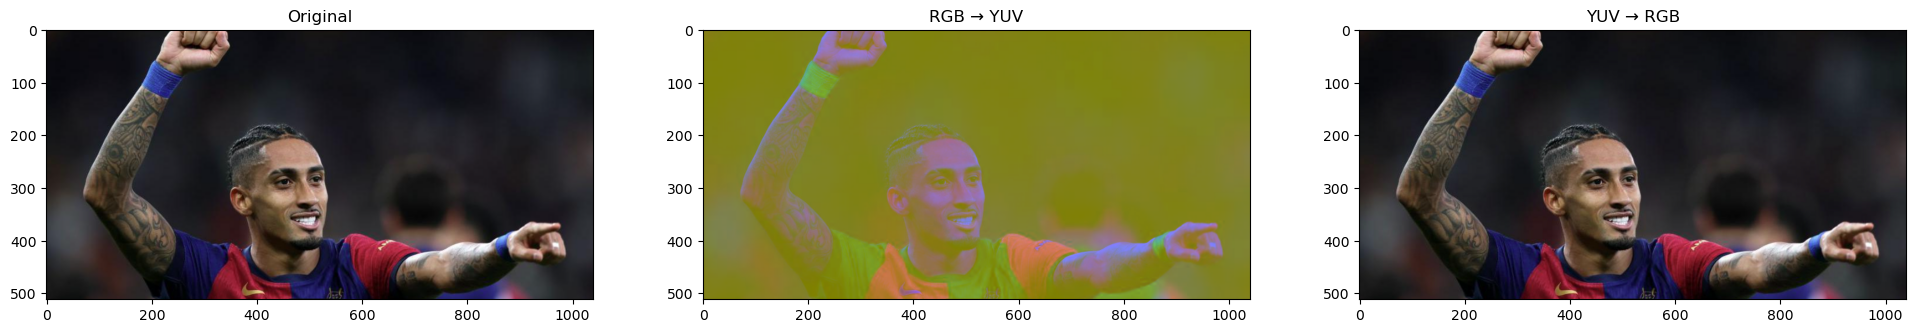

In [ ]:
import cv2
import matplotlib.pyplot as plt
imagen = cv2.imread('A.png',0) 
_,umbral_binario=cv2.threshold(imagen,60,255,cv2.THRESH_BINARY)

_,umbral_binario_inv=cv2.threshold(imagen,100,255,cv2.THRESH_BINARY_INV)

plt.figure(figsize=(24,5))

plt.subplot(1,3,1)
plt.imshow(imagen,cmap='gray')

plt.subplot(1,3,2)
plt.imshow(umbral_binario,cmap='gray')

plt.subplot(1,3,3)
plt.imshow(umbral_binario_inv,cmap='gray')

plt.show()